# 05. Tercera pregunta: ¿influye el contexto social del país?

Esta es la pregunta original del proyecto, la que justifica haber unido dos fuentes
tan distintas. La hipótesis de partida era intuitiva: en los países con mayor
igualdad de género competirían proporcionalmente más mujeres en powerlifting.

La hipótesis no se confirma. Y el proceso de averiguar por qué resulta más
interesante que el resultado que se esperaba, así que este cuaderno documenta el
análisis completo, incluidos los pasos que descartaron una conclusión precipitada.

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import pandas as pd
import numpy as np
from IPython.display import Image, display

import config as cfg
import estilo
import analisis

estilo.aplicar()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

df = analisis.cargar()


CARGA DEL CONJUNTO FINAL


  825,296 filas x 83 columnas   (dataset_final_powerlifting_femenino.csv)


## La unidad de análisis correcta

Un error fácil de cometer sería correlacionar variables a nivel de atleta. Con
825.000 filas cualquier correlación saldría significativa, y el resultado no
significaría nada, porque todas las atletas del mismo país comparten el mismo valor
de contexto.

La unidad correcta es el país-año. Se aplican además dos filtros de calidad: un
mínimo de 40 registros por país-año para que la cuota femenina sea estable, y el uso
exclusivo de indicadores observados, excluyendo las filas donde el valor se propagó
mediante la columna `indicadores_imputados`. No tendría sentido correlacionar con
datos inventados.

In [2]:
analisis.a4_igualdad(df)


A4. PREGUNTA CENTRAL | PARTICIPACION FEMENINA vs IGUALDAD DE GENERO


  Unidad de analisis: pais-anio con >=40 registros y dato observado
  Observaciones: 677  (67 paises, 1990-2022)

  CORRELACION con la cuota de participacion femenina:
  Indicador                            Pearson     p-valor   Spearman     p-valor       n
  Indice desigualdad genero (GII)       +0.089    2.09e-02     -0.053    1.67e-01     673
  Indice desarrollo humano (IDH)        -0.157    4.22e-05     +0.025    5.23e-01     677
  Indice desarrollo genero (GDI)        -0.159    3.24e-05     -0.048    2.12e-01     677
  PIB per capita (PPA)                  -0.034    3.76e-01     -0.033    3.94e-01     677
  Tasa actividad laboral femenina       -0.122    1.51e-03     +0.016    6.83e-01     676
  Matriculacion superior femenina       -0.172    7.27e-06     -0.104    6.80e-03     676



  CUOTA FEMENINA POR NIVEL DE DESIGUALDAD DEL PAIS:
                      count   mean  median    std
grupo_desigualdad                                
Alta desigualdad        175  28.05   26.73  14.28
Baja desigualdad        381  20.28   17.89  13.32
Desigualdad media       219  23.00   20.77  14.31
Muy baja desigualdad    318  23.00   22.30  11.24

  ANOVA           F=14.07  p=5.281e-09
  Kruskal-Wallis  H=70.87  p=2.774e-15

  --------------------------------------------------------------------
  CONTROL DEL EFECTO TEMPORAL (el anio es variable de confusion)
  --------------------------------------------------------------------

  (a) Correlacion PARCIAL controlando el anio:
      Desigualdad genero (GII)       cruda +0.089  ->  parcial +0.082 (p=3.41e-02)
      Desarrollo humano (IDH)        cruda -0.157  ->  parcial -0.154 (p=5.86e-05)
      PIB per capita (PPA)           cruda -0.034  ->  parcial -0.027 (p=4.87e-01)
      Matriculacion superior fem.    cruda -0.172  ->  parcial 

  [figura] a4_igualdad_participacion.png


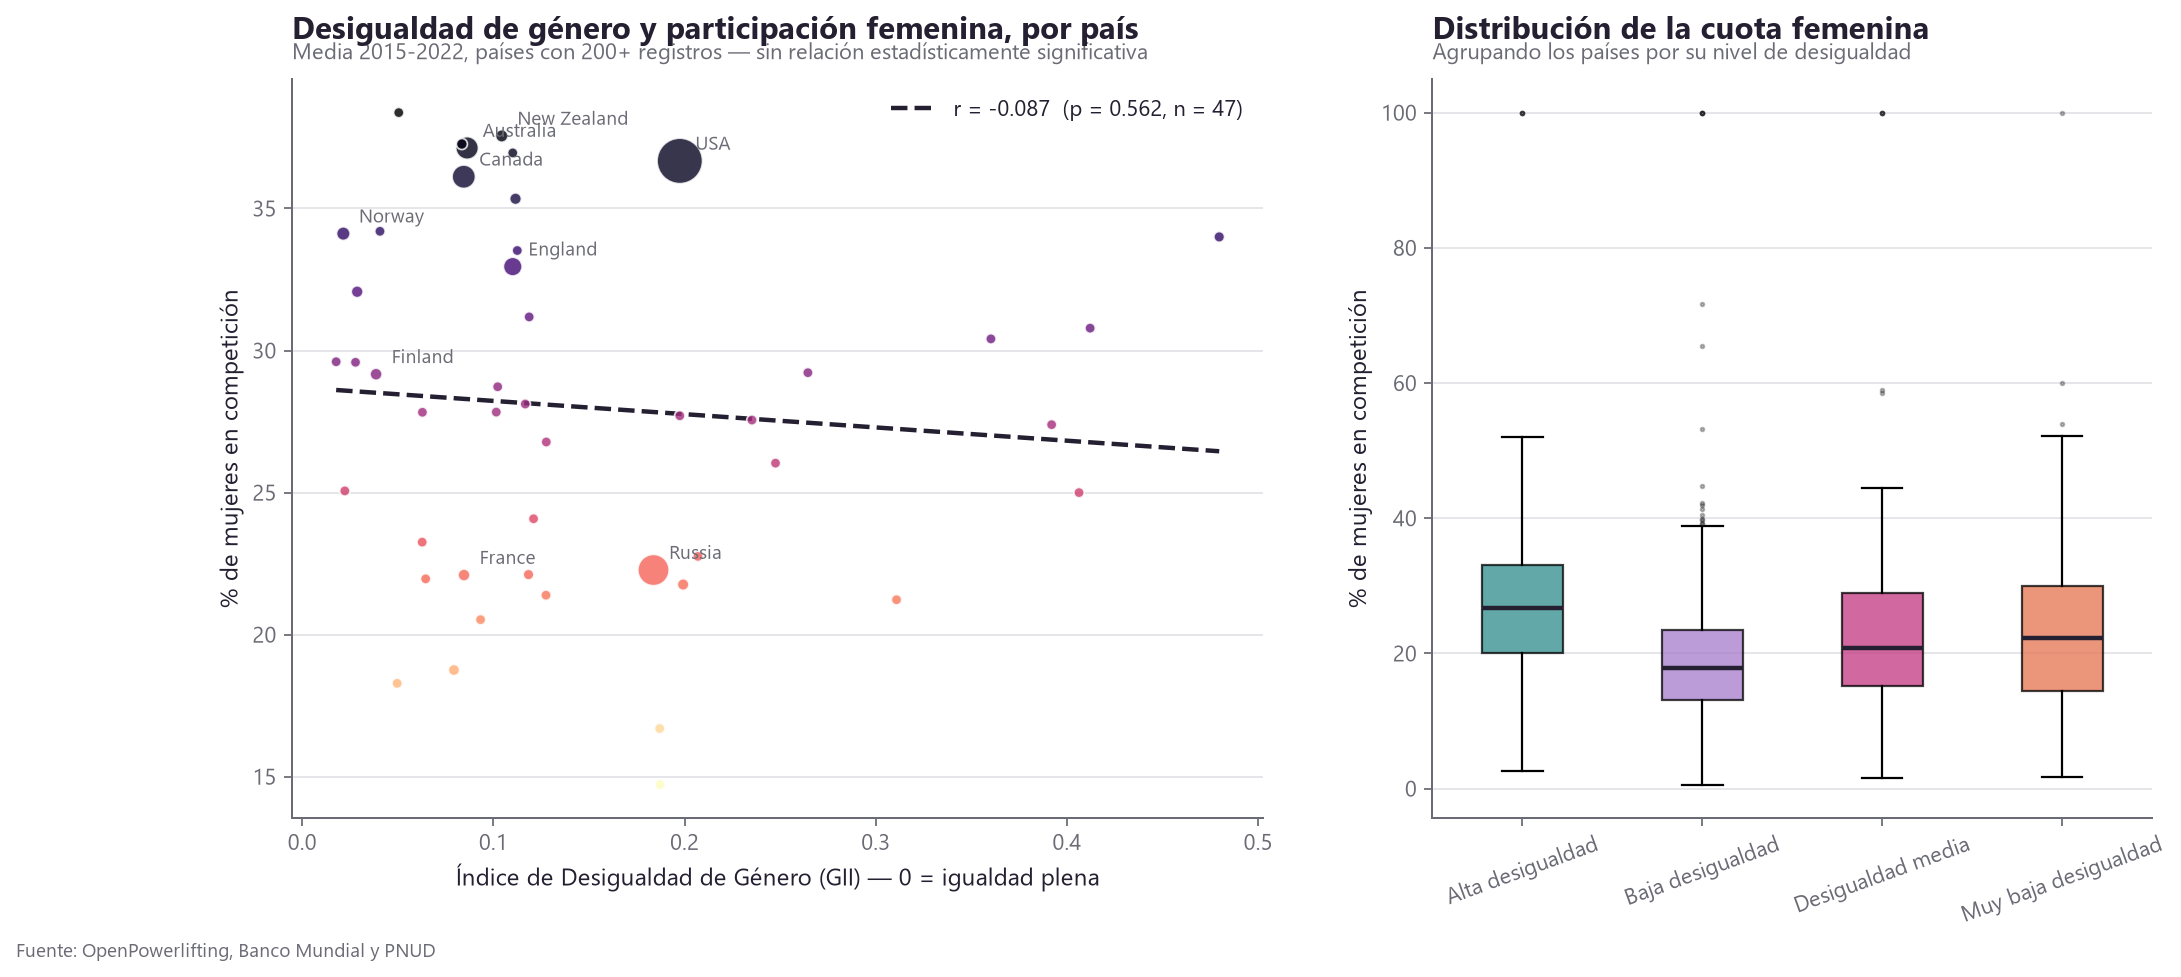

In [3]:
display(Image(filename=str(cfg.FIGURES / "a4_igualdad_participacion.png")))

## Por qué la primera lectura era engañosa

Las correlaciones crudas daban señales débiles y contradictorias. El GII salía con
signo positivo en Pearson pero negativo en Spearman, ninguno con magnitud
apreciable, y el grupo de países de alta desigualdad mostraba la mayor cuota
femenina, justo lo contrario de lo esperado.

Antes de aceptar semejante resultado hay que preguntarse qué lo está produciendo.
Hay dos problemas que lo explican.

El primero es que el año actúa como variable de confusión. La cuota femenina crece
con el tiempo en todos los países, unos 0,9 puntos porcentuales al año, y a la vez,
con el tiempo, el desarrollo humano sube y la desigualdad baja. Como ambas variables
se mueven con el año, correlacionarlas directamente mezcla dos efectos distintos y
puede llegar a invertir el signo. Se aborda de dos formas: correlación parcial,
eliminando de ambas variables la parte explicada por el año, y corte transversal,
tomando un solo valor medio por país en el periodo 2015-2022 para eliminar por
completo la dimensión temporal.

El segundo es el sesgo de Estados Unidos. Con el 68% de los registros, cualquier
correlación global está dominada por la trayectoria interna de un único país y no
por la comparación entre países. Es precisamente lo que el plan denominaba nivel B:
solo el corte transversal entre países comparables permite responder a esta
pregunta.

In [4]:
# Los resultados del analisis, ya calculados: comparacion cruda vs controlada
import json
res = json.load(open(cfg.REPORTS / "resultados_analisis.json", encoding="utf-8"))

print("CORRELACION CRUDA vs PARCIAL (controlando el anio)")
print("-" * 66)
for v in res["correlaciones_parciales"].values():
    print(f"  {v['etiqueta']:<32} cruda {v['r_cruda']:+.3f}  ->  parcial {v['r_parcial']:+.3f}")

CORRELACION CRUDA vs PARCIAL (controlando el anio)
------------------------------------------------------------------
  Desigualdad genero (GII)         cruda +0.089  ->  parcial +0.082
  Desarrollo humano (IDH)          cruda -0.157  ->  parcial -0.154
  PIB per capita (PPA)             cruda -0.034  ->  parcial -0.027
  Matriculacion superior fem.      cruda -0.172  ->  parcial -0.168


In [5]:
print("CORTE TRANSVERSAL ENTRE PAISES (media 2015-2022, 200+ registros)")
print("-" * 74)
print(f"  {'Indicador':<32}{'r':>9}{'p-valor':>10}{'n':>6}   Conclusion")
for v in res["corte_transversal_2015_2022"].values():
    sig = "SIGNIFICATIVA" if v["p"] < 0.05 else "no significativa"
    print(f"  {v['etiqueta']:<32}{v['pearson']:>+9.3f}{v['p']:>10.3f}{v['n']:>6}   {sig}")

CORTE TRANSVERSAL ENTRE PAISES (media 2015-2022, 200+ registros)
--------------------------------------------------------------------------
  Indicador                               r   p-valor     n   Conclusion
  Desigualdad genero (GII)           -0.087     0.562    47   no significativa
  Desarrollo humano (IDH)            +0.248     0.092    47   no significativa
  PIB per capita (PPA)               +0.354     0.015    47   SIGNIFICATIVA
  Matriculacion superior fem.        +0.127     0.395    47   no significativa


## El resultado: no es la igualdad, es la renta

Con el efecto temporal controlado y comparando solo países entre sí, los resultados
son los siguientes:

| Indicador | Correlación | Significativa |
|---|---|---|
| Índice de Desigualdad de Género | −0,087 | No (p=0,56) |
| Índice de Desarrollo Humano | +0,248 | No (p=0,09) |
| PIB per cápita (PPA) | +0,354 | Sí (p=0,015) |
| Matriculación superior femenina | +0,127 | No (p=0,40) |

La hipótesis inicial queda rechazada: la igualdad de género de un país, medida por
el GII, no predice la participación femenina en powerlifting.

Lo que sí la predice es la renta, y tiene una explicación material convincente. El
powerlifting de competición exige recursos: cuota de gimnasio, material,
desplazamientos a competiciones, licencias federativas y, sobre todo, tiempo libre.
La barrera es económica antes que cultural.

Esta reformulación resulta más interesante que la hipótesis original, porque sugiere
que para ampliar la participación femenina en este deporte importan más las
políticas de accesibilidad económica que las campañas de concienciación.

Conviene ser prudente con la magnitud. Con 47 países, una correlación de 0,354
explica alrededor del 12% de la varianza. Es una señal real pero moderada, y queda
mucho que estos indicadores no capturan: la cultura deportiva nacional, la
antigüedad de la federación o la existencia de un circuito local.

In [6]:
# Los paises del corte transversal, ordenados por cuota femenina
corte = pd.DataFrame(res["paises_corte_transversal"])
corte = corte.sort_values("cuota", ascending=False)
print("Mayor cuota femenina (2015-2022):")
print(corte.head(12)[["pais_competicion", "cuota", "gii", "idh", "pib", "registros"]].to_string(index=False))
print("\nMenor cuota femenina:")
print(corte.tail(10)[["pais_competicion", "cuota", "gii", "idh", "pib", "registros"]].to_string(index=False))

Mayor cuota femenina (2015-2022):
pais_competicion  cuota   gii   idh       pib  registros
         Iceland 38.375 0.050 0.955 64332.410        460
     New Zealand 37.554 0.104 0.936 46983.433       3858
         Ireland 37.270 0.083 0.938 97516.618       3013
       Australia 37.130 0.086 0.941 57575.660      12530
        Scotland 36.956 0.110 0.929 51771.018       1741
             USA 36.675 0.198 0.927 68010.555     275304
          Canada 36.118 0.084 0.930 56558.957      13337
              UK 35.341 0.112 0.930 52319.657       3382
             UAE 34.197 0.041 0.934 70492.905        362
          Norway 34.115 0.022 0.960 90319.938       4527
           India 34.000 0.480 0.636  7536.338       2806
       N.Ireland 33.520 0.112 0.930 52143.917        470

Menor cuota femenina:
pais_competicion  cuota   gii   idh       pib  registros
          France 22.096 0.085 0.902 51884.316       3550
         Austria 21.963 0.065 0.917 63158.653        720
         Ukraine 21.762 0.199 0

## La pieza que cierra el argumento

El cuaderno siguiente entrena un modelo predictivo del rendimiento individual, y su
análisis de importancia de variables aporta el complemento decisivo a esta pregunta:
los indicadores socioeconómicos del país tienen una importancia prácticamente nula,
en torno al 0%, para predecir cuánto levanta una atleta.

Juntando ambos resultados se obtiene una conclusión unificada y matizada: el
contexto económico del país influye en quién llega a competir, pero no en cuánto
levanta quien ya compite.

Una vez que una atleta está dentro del sistema competitivo, su rendimiento se
explica por su propia trayectoria y biología, no por el país donde nació. El
contexto actúa como filtro de entrada, no como determinante del techo.

## Síntesis de la tercera pregunta

La igualdad de género no predice la participación femenina, con una r de −0,087 y un
p-valor de 0,56 sobre 47 países. La renta sí lo hace, aunque de forma moderada, con
una r de 0,354 y p de 0,015.

Las correlaciones crudas engañaban porque el año actuaba como variable de confusión.

Y el contexto no explica el rendimiento individual, como muestra la importancia
próxima al 0% en el modelo del cuaderno siguiente,
`06_pregunta4_modelos_ia.ipynb`.